# Outlier Analysis using Ditribution-Aware Group Quantisation

In [1]:
!pip install diffusers transformers accelerate scipy safetensors lpips torch torchvision xformers torchmetrics

In [2]:
import torch
import numpy as np
from diffusers import StableDiffusionPipeline, DDIMScheduler
from torchmetrics.image import StructuralSimilarityIndexMeasure
import lpips
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import json, random

Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


In [11]:
DEVICE    = "cuda"
MODEL_ID  = "CompVis/stable-diffusion-v1-4"
SEED      = 42
N_STEPS   = 50
GUIDANCE  = 7.5

## Helper Functions

In [12]:
def load_coco_captions(path, n=1000, seed=42):
    with open(path) as f:
        data = json.load(f)
    captions = [a["caption"] for a in data["annotations"]]
    random.seed(seed)
    return random.sample(captions, n)

def pil_to_tensor(img):
    """PIL → (1,3,H,W) float32 in [-1,1]"""
    x = torch.from_numpy(np.array(img)).float() / 127.5 - 1.0
    return x.permute(2, 0, 1).unsqueeze(0)

## Hook Infrastructure

In [15]:
# ── Hook infrastructure ───────────────────────────────────────────────────────

class ActivationStore:
    """Stores the first activation seen per layer."""
    def __init__(self):
        self.activations = {}   # layer_name -> tensor (detached, cpu)
        self.handles    = []

    def register(self, unet, target_suffixes):
        for name, module in unet.named_modules():
            if any(name.endswith(s) for s in target_suffixes):
                h = module.register_forward_hook(
                    lambda m, inp, out, n=name:
                        self.activations.update({n: out.detach().cpu()})
                )
                self.handles.append(h)

    def remove(self):
        for h in self.handles:
            h.remove()

# The paper hooks the final output of the FFN in the transformer blocks
TARGET_LAYERS = [
    "down_blocks.0.attentions.0.transformer_blocks.0.ff.net.2", # Layer from Fig 4b
    "up_blocks.1.attentions.2.transformer_blocks.0.ff.net.2"     # Another sensitive point
]

# ── Core generation with optional activation zeroing ─────────────────────────

def generate(pipe, prompt, activation_store=None,
             zero_mode=None, zero_layer=None, zero_idx=None):
    """
    zero_mode: None | 'random' | 'outlier'
    If not None, zeroes one activation per layer during the forward pass.
    """
    generator = torch.Generator(DEVICE).manual_seed(SEED)

    if zero_mode is not None:
        # Patch: after first forward hook fires, zero the chosen activation
        modified = {}

        def make_zero_hook(layer_name):
            def hook(module, inp, out):
                generator = torch.Generator(device="cpu").manual_seed(SEED)  # same seed for reproducibility
                act = out.clone()
                flat = act.view(-1)  # flatten to 1D for easy indexing
        
                if zero_mode == 'random':
                    num_drop = max(1, int(flat.numel() * 0.1))
                    indices = torch.randperm(flat.numel(), generator=generator)[:num_drop]
                    flat[indices] = 0.0
                elif zero_mode == 'outlier':
                     num_drop = max(1, int(flat.numel() * 0.1))
                     _, indices = torch.topk(flat.abs(), k=num_drop)
                     flat[indices] = 0.0
                return act.reshape(out.shape)
            return hook

        handles = []
        for name, module in pipe.unet.named_modules():
            if name == zero_layer:
                handles.append(module.register_forward_hook(make_zero_hook(name)))

    with torch.no_grad():
        out = pipe(prompt,
                   num_inference_steps=N_STEPS,
                   guidance_scale=GUIDANCE,
                   generator=generator)

    if zero_mode is not None:
        for h in handles:
            h.remove()

    return out.images[0]

# ── Table 1 reproduction ─────────────────────────────────────────────────────

def reproduce_table1(pipe, prompts, lpips_fn):
    """
    For each prompt: generate reference, random-drop image, outlier-drop image.
    Returns mean PSNR and LPIPS for each condition.
    Paper reports:
        random drop  → PSNR 17.81, LPIPS 0.295
        outlier drop → PSNR  9.34, LPIPS 0.773
    """
    results = {"random": {"psnr": [], "lpips": []},
               "outlier": {"psnr": [], "lpips": []}}

    for prompt in prompts:
        ref_img = generate(pipe, prompt)
        ref_t   = pil_to_tensor(ref_img).to(DEVICE)

        for mode in ("random", "outlier"):
            # Apply to every target layer and average
            layer_psnrs, layer_lpips = [], []
            for layer in TARGET_LAYERS:
                mod_img = generate(pipe, prompt,
                                   zero_mode=mode, zero_layer=layer)
                mod_t   = pil_to_tensor(mod_img).to(DEVICE)

                # PSNR
                mse  = ((ref_t - mod_t) ** 2).mean().item()
                psnr = 10 * np.log10(4.0 / mse) if mse > 0 else 100.0
                layer_psnrs.append(psnr)

                # LPIPS
                lp = lpips_fn(ref_t, mod_t).item()
                layer_lpips.append(lp)

            results[mode]["psnr"].append(np.mean(layer_psnrs))
            results[mode]["lpips"].append(np.mean(layer_lpips))

    print("\n── Table 1 reproduction ──────────────────────────")
    print(f"{'Method':<20} {'PSNR↑':>8} {'LPIPS↓':>8}")
    print(f"{'random drop':<20} {np.mean(results['random']['psnr']):>8.2f}"
          f" {np.mean(results['random']['lpips']):>8.3f}")
    print(f"{'outlier drop':<20} {np.mean(results['outlier']['psnr']):>8.2f}"
          f" {np.mean(results['outlier']['lpips']):>8.3f}")
    print("  Paper: random 17.81 / 0.295 | outlier 9.34 / 0.773")
    return results

# ── Figure 4(a): qualitative comparison ──────────────────────────────────────

def plot_figure4a(pipe, prompts_2, save_path="fig4a_qualitative.pdf"):
    """
    Reproduces Figure 4(a): 3 columns × 2 rows.
    Columns: Original | Random drop | Outlier drop
    Rows: two prompts from prompts_2
    """
    fig, axes = plt.subplots(2, 3, figsize=(12, 8))
    col_titles = ["Original", "Random drop", "Outlier drop"]
    for col, title in enumerate(col_titles):
        axes[0, col].set_title(title, fontsize=11, fontweight='bold')

    for row, prompt in enumerate(prompts_2):
        ref_img = generate(pipe, prompt)

        # Use first target layer for the qualitative demo
        rand_img    = generate(pipe, prompt,
                               zero_mode='random',  zero_layer=TARGET_LAYERS[0])
        outlier_img = generate(pipe, prompt,
                               zero_mode='outlier', zero_layer=TARGET_LAYERS[0])

        for col, img in enumerate([ref_img, rand_img, outlier_img]):
            axes[row, col].imshow(img)
            axes[row, col].axis('off')

        axes[row, 0].set_ylabel(f'"{prompt[:40]}…"',
                                fontsize=8, rotation=0,
                                labelpad=120, va='center')

    plt.tight_layout()
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    print(f"Saved → {save_path}")
    plt.show()

# ── Figure 4(b): pixel-wise and channel-wise boxplots ────────────────────────

def plot_figure4b(pipe, prompt, save_path="fig4b_boxplots.pdf"):
    """
    Reproduces Figure 4(b): two boxplot panels.
    Left:  pixel-wise  — one box per spatial position (H*W boxes), showing
           that a few positions have extreme ranges → Case 1
    Right: channel-wise — one box per channel (C boxes), showing that a few
           channels have extreme ranges → Case 2

    We hook the FFN output (a good layer to show both outlier types).
    """
    store = ActivationStore()
    store.register(pipe.unet, ["ff.net.2"])

    with torch.no_grad():
        pipe(prompt,
             num_inference_steps=N_STEPS,
             guidance_scale=GUIDANCE,
             generator=torch.Generator(DEVICE).manual_seed(SEED))

    store.remove()

    # Get the activation from the first hooked layer
    layer_name = [k for k in store.activations if "ff.net.2" in k][0]
    act = store.activations[layer_name]   # shape: (B, T, C) or (B, C, H, W)

    if act.dim() == 4:
        # (B, C, H, W) → (H*W, C)
        B, C, H, W = act.shape
        act_hw = act[0].permute(1, 2, 0).reshape(H * W, C).numpy()
    else:
        # (B, T, C) → (T, C)
        act_hw = act[0].numpy()   # (T, C)

    T, C = act_hw.shape

    # Subsample for tractable plotting (paper shows ~50-100 boxes)
    # Pick the 64 positions/channels with highest absolute max
    n_show = 64

    # ── Left: pixel-wise (one box per spatial token) ─────────────────────────
    token_ranges = act_hw.max(axis=1) - act_hw.min(axis=1)
    top_token_idx = np.argsort(token_ranges)[::-1][:n_show]
    top_token_idx_sorted = np.sort(top_token_idx)
    pixel_data = [act_hw[i, :] for i in top_token_idx_sorted]

    # ── Right: channel-wise (one box per channel) ─────────────────────────────
    chan_ranges = act_hw.max(axis=0) - act_hw.min(axis=0)
    top_chan_idx = np.argsort(chan_ranges)[::-1][:n_show]
    top_chan_idx_sorted = np.sort(top_chan_idx)
    chan_data = [act_hw[:, c] for c in top_chan_idx_sorted]

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle("Activation outlier characteristics (replicating DGQ Fig. 4b)",
                 fontsize=11)

    # Pixel-wise boxplot
    ax1.boxplot(pixel_data, positions=range(n_show),
                widths=0.6, patch_artist=True,
                boxprops=dict(facecolor='lightblue', alpha=0.7),
                medianprops=dict(color='navy'),
                flierprops=dict(marker='.', markersize=2, alpha=0.3),
                whiskerprops=dict(linewidth=0.8),
                showcaps=True)
    ax1.set_xlabel("Pixel index (top-64 by range)", fontsize=10)
    ax1.set_ylabel("Activation value", fontsize=10)
    ax1.set_title("Case 1: Outliers on specific pixels\n(pixel-wise boxplot)",
                  fontsize=10)
    ax1.set_xticks(range(0, n_show, 8))

    # Channel-wise boxplot
    ax2.boxplot(chan_data, positions=range(n_show),
                widths=0.6, patch_artist=True,
                boxprops=dict(facecolor='lightsalmon', alpha=0.7),
                medianprops=dict(color='darkred'),
                flierprops=dict(marker='.', markersize=2, alpha=0.3),
                whiskerprops=dict(linewidth=0.8),
                showcaps=True)
    ax2.set_xlabel("Channel index (top-64 by range)", fontsize=10)
    ax2.set_ylabel("Activation value", fontsize=10)
    ax2.set_title("Case 2: Outliers on specific channels\n(channel-wise boxplot)",
                  fontsize=10)
    ax2.set_xticks(range(0, n_show, 8))

    plt.tight_layout()
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    print(f"Saved → {save_path}")
    plt.show()

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_validators.py:205: UserWarning: The `local_dir_use_symlinks` argument is deprecated and ignored in `hf_hub_download`. Downloading to a local directory does not use symlinks anymore.
  warnings.warn(


Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/396 [00:00<?, ?it/s]

StableDiffusionSafetyChecker LOAD REPORT from: /root/.cache/huggingface/hub/models--CompVis--stable-diffusion-v1-4/snapshots/133a221b8aa7292a167afc5127cb63fb5005638b/safety_checker
Key                                               | Status     |  | 
--------------------------------------------------+------------+--+-
vision_model.vision_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

CLIPTextModel LOAD REPORT from: /root/.cache/huggingface/hub/models--CompVis--stable-diffusion-v1-4/snapshots/133a221b8aa7292a167afc5127cb63fb5005638b/text_encoder
Key                                | Status     |  | 
-----------------------------------+------------+--+-
text_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Setting up [LPIPS] perceptual loss: trunk [alex], v[0.1], spatial [off]


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=AlexNet_Weights.IMAGENET1K_V1`. You can also use `weights=AlexNet_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Loading model from: /usr/local/lib/python3.12/dist-packages/lpips/weights/v0.1/alex.pth
Running Quantitative Comparison (Table 1)...

── Table 1 reproduction ──────────────────────────
Method                  PSNR↑   LPIPS↓
random drop             26.23    0.084
outlier drop            20.94    0.225
  Paper: random 17.81 / 0.295 | outlier 9.34 / 0.773

Generating Qualitative Comparison (Figure 4a)...
Saved → fig4a_qualitative.pdf


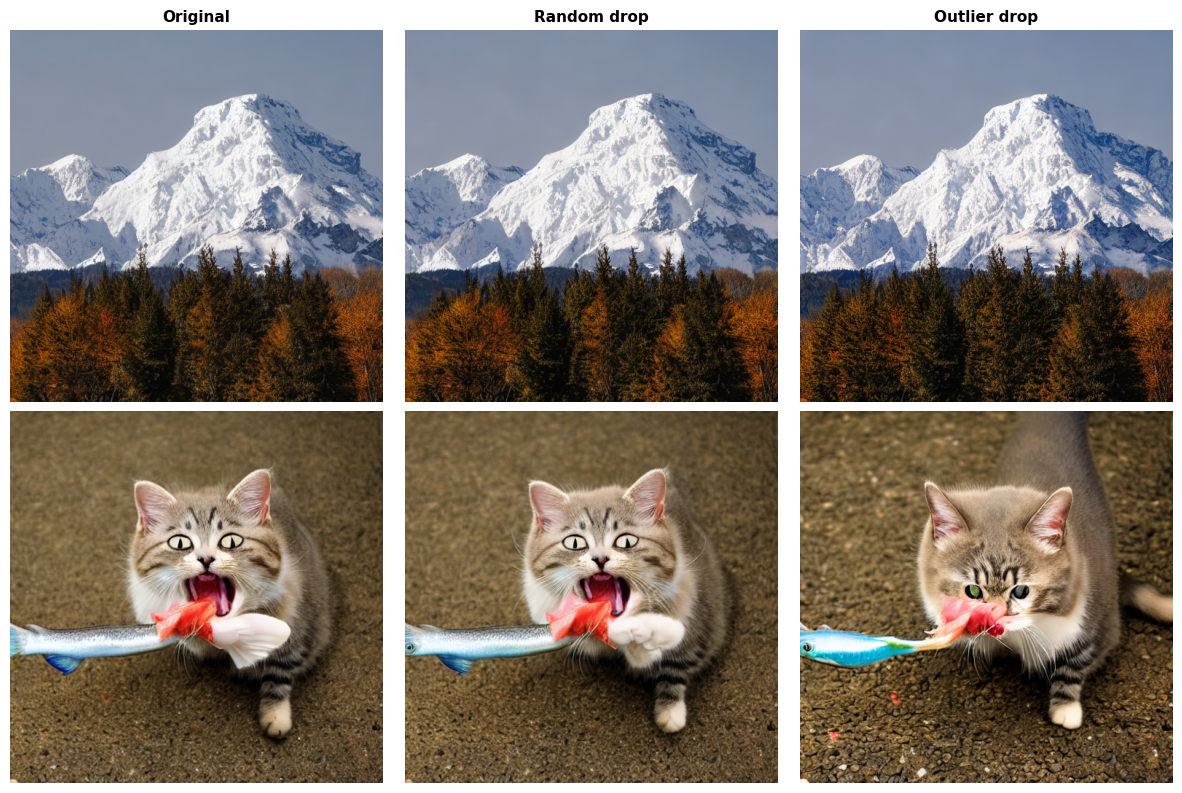


Generating Outlier Boxplots (Figure 4b)...
Saved → fig4b_boxplots.pdf


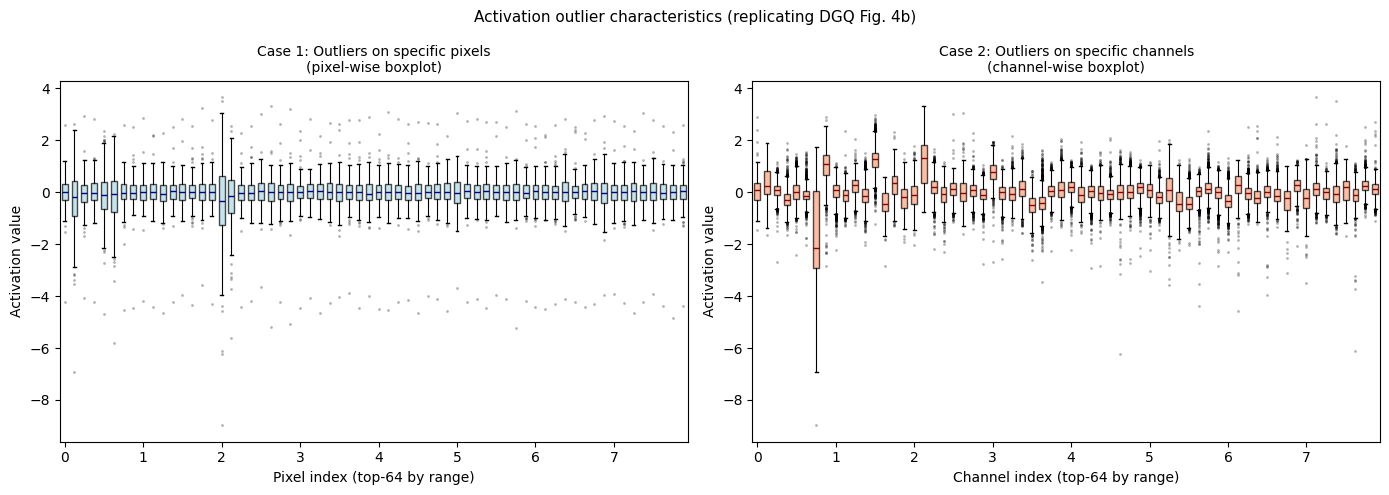

In [16]:
if __name__ == "__main__":
    # 1. Initialize the Pipeline and LPIPS metric
    # DGQ focuses on Stable Diffusion v1.4 [cite: 37, 123]
    pipe = StableDiffusionPipeline.from_pretrained(
        MODEL_ID,
        torch_dtype=torch.float16,
        scheduler=DDIMScheduler.from_pretrained(MODEL_ID, subfolder="scheduler")
    ).to(DEVICE)
    pipe.set_progress_bar_config(disable=True)

    lpips_fn = lpips.LPIPS(net='alex').to(DEVICE)

    # 2. Define a small set of representative prompts
    # These prompts are used in the paper's qualitative analysis [cite: 187, 189]
    captions = [
        "A mountain with snow-capped peaks rising high into the sky.",
        "A cute cat, eating a fish, with a big smile on its face.",
        "A smiling teddy bear.",
        "A sports car running on Mars."
    ]

    # 3. Reproduce Table 1 (Quantitative Analysis)
    # This evaluates how much image quality degrades when an outlier is zeroed [cite: 204, 208]
    print("Running Quantitative Comparison (Table 1)...")
    reproduce_table1(pipe, captions, lpips_fn)

    # 4. Reproduce Figure 4a (Qualitative Comparison)
    # This generates the 3-column visual comparison seen in the paper [cite: 192]
    print("\nGenerating Qualitative Comparison (Figure 4a)...")
    plot_figure4a(pipe, captions[:2])

    # 5. Reproduce Figure 4b (Distribution Analysis)
    # This traces outliers to specific pixels or channels [cite: 193, 211]
    print("\nGenerating Outlier Boxplots (Figure 4b)...")
    plot_figure4b(pipe, captions[0])